<a href="https://colab.research.google.com/github/clarissachng/ClarissaChngSiEn_COMS30045_IndividualProject/blob/main/3_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup & data loading

- Mount Drive, import libraries
- Load `llm_results`, `nlp_results` pickles
- Define `EMOTIONS`, `TASTES`, constants
- Download Kaggle dataset, build `image_lookup`

In [ ]:
import pickle
from google.colab import drive
drive.mount('/content/drive')

with open("/content/drive/MyDrive/dataset/llm_rankings.pkl", "rb") as f:
    llm_results = pickle.load(f)

with open("/content/drive/MyDrive/dataset/nlp_rankings.pkl", "rb") as f:
    nlp_results = pickle.load(f)

print("LLM emotions:", list(llm_results["emotion"].keys()))
print("LLM tastes:  ", list(llm_results["taste"].keys()))
print("NLP emotions:", list(nlp_results["emotion"].keys()))
print("NLP tastes:  ", list(nlp_results["taste"].keys()))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
LLM emotions: ['happy', 'pleasure', 'astonished', 'relaxed', 'satisfied', 'tired', 'fear', 'angry', 'annoyed', 'sad', 'disgust', 'droopy']
LLM tastes:   ['sweet', 'sour', 'salty', 'bitter', 'umami']
NLP emotions: ['happy', 'pleasure', 'asthonished', 'relaxed', 'satisfied', 'tired', 'fear', 'angry', 'annoyed', 'sad', 'disgust', 'droopy']
NLP tastes:   ['sweet', 'sour', 'salty', 'bitter', 'umami']


In [ ]:
import kagglehub

dataset_path = kagglehub.dataset_download("mexwell/book-cover-dataset")

Using Colab cache for faster access to the 'book-cover-dataset' dataset.


In [ ]:
EMOTIONS = [
    'Happy', 'Pleasure', 'Astonished', 'Relaxed', 'Satisfied',
    'Tired', 'Fear', 'Angry', 'Annoyed', 'Sad', 'Disgust', 'Droopy'
]

TASTES = ['Sweet', 'Sour', 'Salty', 'Bitter', 'Umami']

N_BOOKS = 60   # real books per study (trials excluded)

print(f'Emotions ({len(EMOTIONS)}): {EMOTIONS}')
print(f'Tastes   ({len(TASTES)}):   {TASTES}')

Emotions (12): ['Happy', 'Pleasure', 'Astonished', 'Relaxed', 'Satisfied', 'Tired', 'Fear', 'Angry', 'Annoyed', 'Sad', 'Disgust', 'Droopy']
Tastes   (5):   ['Sweet', 'Sour', 'Salty', 'Bitter', 'Umami']


#  CLIP vs NLP agreement (existing work)

- Spearman correlation function + compute for emotion & taste
- Bar chart visualisation
- Summary stats printout

In [ ]:
from scipy.stats import spearmanr
import pandas as pd
import numpy as np

def compute_spearman(nlp_rankings, llm_rankings):
    """
    Aligns books common to both rankings,
    converts to rank positions, computes Spearman rho + p-value.
    """
    results = []

    for label in nlp_rankings:
        if label not in llm_rankings:
            print(f"  WARNING: '{label}' missing from LLM rankings — skipping")
            continue

        # Each ranking is [(filename, score), ...] sorted best first
        nlp_filenames = [fname for fname, _ in nlp_rankings[label]]
        llm_filenames = [fname for fname, _ in llm_rankings[label]]

        # Common books only
        common = [b for b in nlp_filenames if b in llm_filenames]

        if len(common) < 3:
            print(f"  WARNING: '{label}' has fewer than 3 common books — skipping")
            continue

        nlp_ranks = [nlp_filenames.index(b) + 1 for b in common]
        llm_ranks = [llm_filenames.index(b) + 1 for b in common]

        rho, pval = spearmanr(nlp_ranks, llm_ranks)

        results.append({
            "Label":        label,
            "Spearman ρ":   round(rho,  4),
            "p-value":      round(pval, 4),
            "Significant":  "✓" if pval < 0.05 else "✗",
            "N books":      len(common),
        })

    return pd.DataFrame(results).set_index("Label")

print("EMOTION — NLP vs LLM Spearman Correlation")
emotion_spearman = compute_spearman(nlp_results["emotion"], llm_results["emotion"])
print(emotion_spearman.to_string())

print("TASTE — NLP vs LLM Spearman Correlation")
taste_spearman = compute_spearman(nlp_results["taste"], llm_results["taste"])
print(taste_spearman.to_string())

EMOTION — NLP vs LLM Spearman Correlation


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

datasets = [
    (emotion_spearman, "Emotion Agreement"),
    (taste_spearman,   "Taste Agreement"),
]

for ax, (df, title) in zip(axes, datasets):
    labels = df.index.tolist()
    rhos   = df["Spearman ρ"].values
    x      = np.arange(len(labels))

    # Colour bars by strength: green ≥ 0.9, orange ≥ 0.7, red otherwise
    colors = ["#2ecc71" if r >= 0.9 else "#e67e22" if r >= 0.7 else "#e74c3c" for r in rhos]

    bars = ax.bar(x, rhos, color=colors, width=0.6, edgecolor="white", linewidth=0.8)

    # Annotate each bar with its value
    for bar, rho in zip(bars, rhos):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.008,
            f"{rho:.3f}",
            ha="center", va="bottom",
            fontsize=9, fontweight="bold"
        )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=40, ha="right", fontsize=10)
    ax.set_ylim(0, 1.08)
    ax.set_ylabel("Spearman ρ", fontsize=11)
    ax.set_title(title, fontweight="bold", fontsize=13, pad=12)
    ax.spines[["top", "right"]].set_visible(False)

    # Legend patches
    legend_patches = [
        mpatches.Patch(color="#2ecc71", label="Strong (ρ ≥ 0.9)"),
        mpatches.Patch(color="#e67e22", label="Moderate (ρ ≥ 0.7)"),
        mpatches.Patch(color="#e74c3c", label="Weak (ρ < 0.7)"),
    ]
    ax.legend(handles=legend_patches, fontsize=8, loc="lower right")

fig.suptitle(
    "Spearman Rank Correlation: NLP vs LLM Book Rankings",
    fontsize=15, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.show()

In [ ]:
print("SUMMARY")

for name, df in [("Emotion", emotion_spearman), ("Taste", taste_spearman)]:
    rhos = df["Spearman ρ"]
    sig  = (df["p-value"] < 0.05).sum()
    print(f"\n{name}:")
    print(f"  Mean ρ:        {rhos.mean():.4f}")
    print(f"  Max ρ:         {rhos.max():.4f}  ({rhos.idxmax()})")
    print(f"  Min ρ:         {rhos.min():.4f}  ({rhos.idxmin()})")
    print(f"  Significant:   {sig}/{len(df)} labels (p < 0.05)")

# Build CLIP matrices

- Build 60-book pool (greedy top-5 per emotion)
- Build binary emotion matrix (60×12) and taste matrix (60×5)
- Build raw score emotion matrix (60×12) and taste matrix (60×5)

- Heatmap: binary emotion
- Heatmap: binary taste
- Heatmap: raw score emotion
- Heatmap: raw score taste

In [ ]:
import os, glob
import numpy as np
import pandas as pd
from PIL import Image

# Build filename → full path lookup from the Kaggle download
all_images = (
    glob.glob(os.path.join(dataset_path, '**/*.jpg'),  recursive=True) +
    glob.glob(os.path.join(dataset_path, '**/*.jpeg'), recursive=True) +
    glob.glob(os.path.join(dataset_path, '**/*.png'),  recursive=True)
)
image_lookup = {os.path.basename(p): p for p in all_images}
print(f'Kaggle images indexed: {len(image_lookup):,}')

EMOTIONS_LOWER = [e.lower() for e in EMOTIONS]
TASTES_LOWER   = [t.lower() for t in TASTES]

# Reconstruct ordered 60-book pool (top-5 per emotion, greedy/no repeats)
pool_entries = []
used = set()

for emotion_label in EMOTIONS_LOWER:
    key = emotion_label
    if key not in llm_results['emotion']:
        alt = [k for k in llm_results['emotion'] if 'astonish' in k]
        key = alt[0] if alt else None
    if key is None: continue
    added = 0
    for fname, score in llm_results['emotion'][key]:
        if fname not in used and added < 5:
            pool_entries.append({
                'fname':        fname,
                'fpath':        image_lookup.get(fname),   # resolve full path
                'clip_emotion': emotion_label,
                'emotion_score': score,
            })
            used.add(fname)
            added += 1

# Assign top-1 CLIP taste per pool book
taste_score_lookup = {
    t: {fname: score for fname, score in llm_results['taste'][t]}
    for t in TASTES_LOWER
}
for entry in pool_entries:
    fname = entry['fname']
    taste_scores = {t: taste_score_lookup[t].get(fname, -999) for t in TASTES_LOWER}
    entry['clip_taste'] = max(taste_scores, key=taste_scores.get)

# Build binary matrices
N = len(pool_entries)
clip_emotion_matrix = np.zeros((N, len(EMOTIONS)), dtype=int)  # (60, 12)
clip_taste_matrix   = np.zeros((N, len(TASTES)),   dtype=int)  # (60,  5)

for i, entry in enumerate(pool_entries):
    e = entry['clip_emotion']
    t = entry['clip_taste']
    e_clean = 'astonished' if 'astonish' in e else e
    if e_clean in EMOTIONS_LOWER:
        clip_emotion_matrix[i, EMOTIONS_LOWER.index(e_clean)] = 1
    if t in TASTES_LOWER:
        clip_taste_matrix[i, TASTES_LOWER.index(t)] = 1

pool_image_paths = [entry['fpath'] for entry in pool_entries]
pool_emotions    = [entry['clip_emotion'] for entry in pool_entries]

missing = sum(1 for p in pool_image_paths if p is None)
print(f'Pool: {N} books | Images resolved: {N - missing}/{N} (missing: {missing})')
print(f'clip_emotion_matrix: {clip_emotion_matrix.shape}')
print(f'clip_taste_matrix:   {clip_taste_matrix.shape}')

Kaggle images indexed: 57,000
Pool: 60 books | Images resolved: 60/60 (missing: 0)
clip_emotion_matrix: (60, 12)
clip_taste_matrix:   (60, 5)


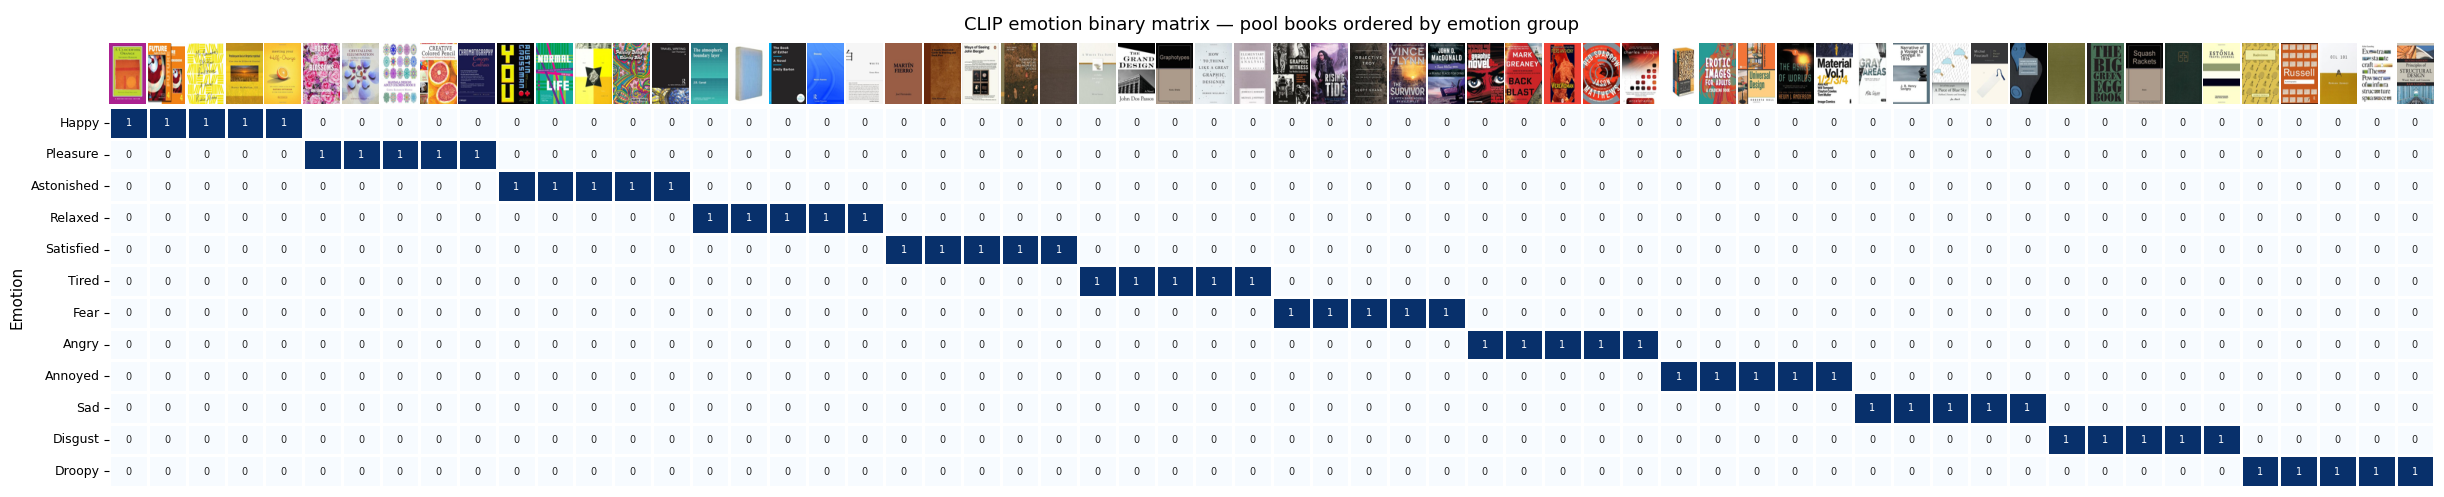

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns

# Colour each emotion group distinctly for the header band
EMOTION_COLORS = {
    'happy':'#97C459', 'pleasure':'#5DCAA5', 'astonished':'#FAC775',
    'relaxed':'#85B7EB', 'satisfied':'#AFA9EC', 'tired':'#B4B2A9',
    'fear':'#F09595', 'angry':'#E24B4A', 'annoyed':'#D85A30',
    'sad':'#378ADD', 'disgust':'#639922', 'droopy':'#888780',
}

df_clip_emotion = pd.DataFrame(
    clip_emotion_matrix.T,
    index=EMOTIONS,
    columns=[f'B{i+1:02d}' for i in range(N)]
)

THUMB_H  = 0.8
MATRIX_H = 5.0
TOTAL_W  = 30

fig = plt.figure(figsize=(TOTAL_W, 0.4 + THUMB_H + MATRIX_H))
gs  = gridspec.GridSpec(3, N,
        height_ratios=[0.4, THUMB_H, MATRIX_H],
        hspace=0.02, wspace=0.05)

# Row 0: title in its own dedicated row
ax_title = fig.add_subplot(gs[0, :])
ax_title.axis('off')
ax_title.text(
    0.5, 0.5,
    'CLIP emotion binary matrix — pool books ordered by emotion group',
    ha='center', va='center',
    fontsize=13, fontweight='normal',
    transform=ax_title.transAxes
)

# Row 1: thumbnails + emotion colour border
for col_i, (path, em) in enumerate(zip(pool_image_paths, pool_emotions)):
    ax_img = fig.add_subplot(gs[1, col_i])
    ax_img.axis('off')
    color = EMOTION_COLORS.get(em, '#ccc')
    for spine in ax_img.spines.values():
        spine.set_edgecolor(color); spine.set_linewidth(3); spine.set_visible(True)
    if path and os.path.exists(path):
        try:
            img = Image.open(path).convert('RGB')
            img.thumbnail((80, 120))
            ax_img.imshow(np.array(img), aspect='auto')
        except:
            ax_img.set_facecolor('#eee')
    else:
        ax_img.set_facecolor('#eee')

# heatmap
ax_heat = fig.add_subplot(gs[2, :])
sns.heatmap(
    df_clip_emotion,
    ax=ax_heat,
    annot=True,
    fmt='',
    annot_kws={'size': 7},
    cmap='Blues', vmin=0, vmax=1,
    linewidths=0.8, linecolor='white',
    cbar=False,
)
ax_heat.set_xlabel('')
ax_heat.set_ylabel('Emotion', fontsize=11)
ax_heat.tick_params(axis='x', bottom=False, labelbottom=False)
ax_heat.tick_params(axis='y', rotation=0, labelsize=9)


plt.savefig('clip_emotion_binary_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Raw score matrices ───────────────────────────────────────────────────────
clip_emotion_scores = np.zeros((N, len(EMOTIONS_LOWER)), dtype=float)
for j, emotion_label in enumerate(EMOTIONS_LOWER):
    key = emotion_label
    if key not in llm_results['emotion']:
        alt = [k for k in llm_results['emotion'] if 'astonish' in k]
        key = alt[0] if alt else None
    if key is None:
        continue
    score_dict = {fname: score for fname, score in llm_results['emotion'][key]}
    for i, entry in enumerate(pool_entries):
        clip_emotion_scores[i, j] = score_dict.get(entry['fname'], 0.0)

clip_taste_scores = np.zeros((N, len(TASTES_LOWER)), dtype=float)
for j, taste_label in enumerate(TASTES_LOWER):
    score_dict = {fname: score for fname, score in llm_results['taste'][taste_label]}
    for i, entry in enumerate(pool_entries):
        clip_taste_scores[i, j] = score_dict.get(entry['fname'], 0.0)

print(f'clip_emotion_scores: {clip_emotion_scores.shape}')
print(f'clip_taste_scores:   {clip_taste_scores.shape}')

clip_emotion_scores: (60, 12)
clip_taste_scores:   (60, 5)


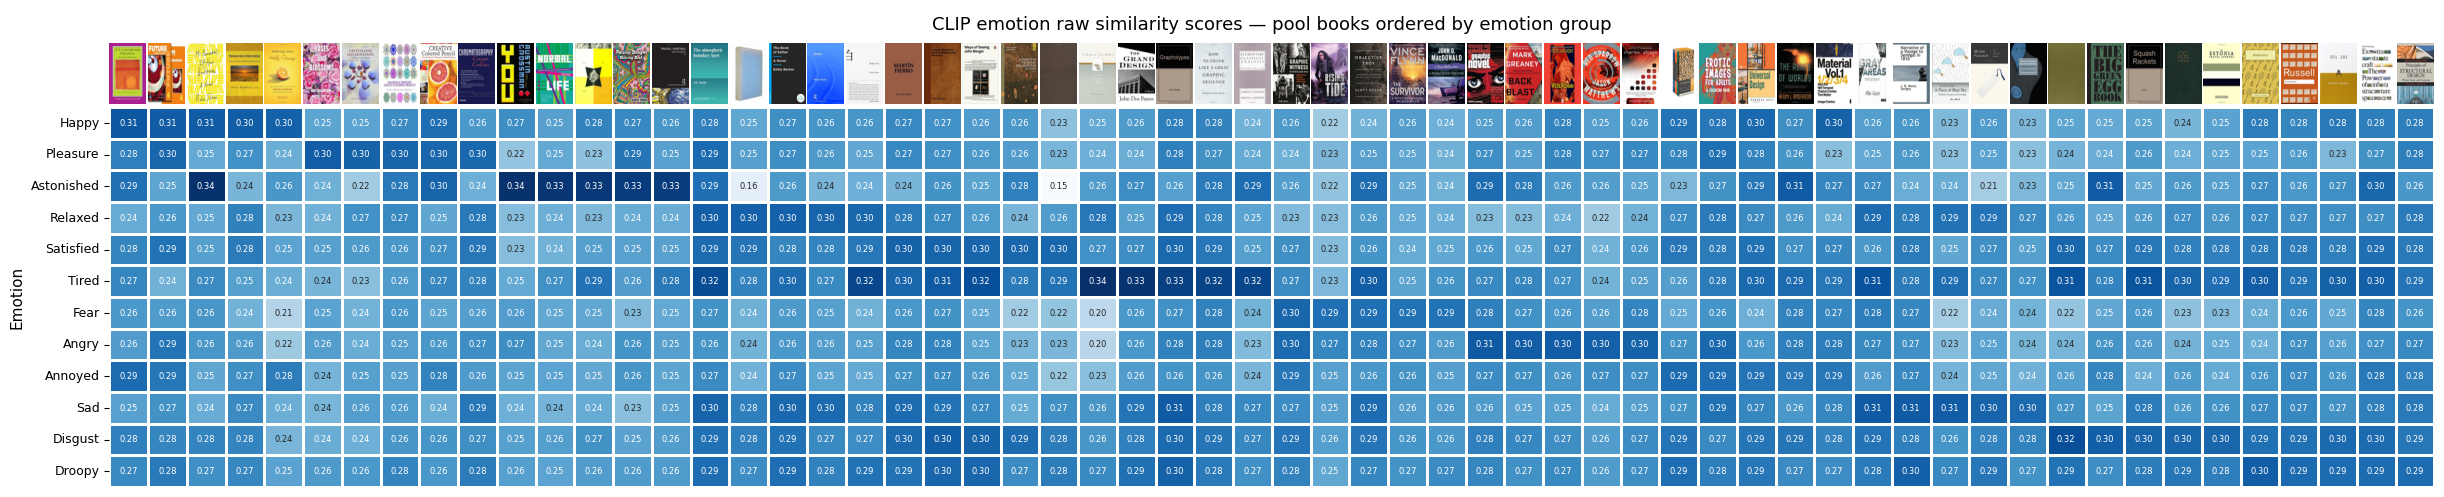

In [ ]:
df_clip_emotion_raw = pd.DataFrame(
    clip_emotion_scores.T,
    index=EMOTIONS,
    columns=[f'B{i+1:02d}' for i in range(N)]
)

THUMB_H  = 0.8
MATRIX_H = 5.0
TOTAL_W  = 30

fig = plt.figure(figsize=(TOTAL_W, 0.4 + THUMB_H + MATRIX_H))
gs  = gridspec.GridSpec(3, N,
        height_ratios=[0.4, THUMB_H, MATRIX_H],
        hspace=0.02, wspace=0.05)

# Row 0: title
ax_title = fig.add_subplot(gs[0, :])
ax_title.axis('off')
ax_title.text(
    0.5, 0.5,
    'CLIP emotion raw similarity scores — pool books ordered by emotion group',
    ha='center', va='center',
    fontsize=13, fontweight='normal',
    transform=ax_title.transAxes
)

# Row 1: thumbnails — exactly the same as binary cell
for col_i, (path, em) in enumerate(zip(pool_image_paths, pool_emotions)):
    ax_img = fig.add_subplot(gs[1, col_i])
    ax_img.axis('off')
    color = EMOTION_COLORS.get(em, '#ccc')
    for spine in ax_img.spines.values():
        spine.set_edgecolor(color); spine.set_linewidth(3); spine.set_visible(True)
    if path and os.path.exists(path):
        try:
            img = Image.open(path).convert('RGB')
            img.thumbnail((80, 120))
            ax_img.imshow(np.array(img), aspect='auto')
        except:
            ax_img.set_facecolor('#eee')
    else:
        ax_img.set_facecolor('#eee')

# Row 2: heatmap — only this part differs from the binary cell
ax_heat = fig.add_subplot(gs[2, :])
sns.heatmap(
    df_clip_emotion_raw,
    ax=ax_heat,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 6},
    cmap='Blues',
    linewidths=0.8, linecolor='white',
    cbar=False,
)
ax_heat.set_xlabel('')
ax_heat.set_ylabel('Emotion', fontsize=11)
ax_heat.tick_params(axis='x', bottom=False, labelbottom=False)
ax_heat.tick_params(axis='y', rotation=0, labelsize=9)

plt.savefig('clip_emotion_raw_scores.png', dpi=150, bbox_inches='tight')
plt.show()

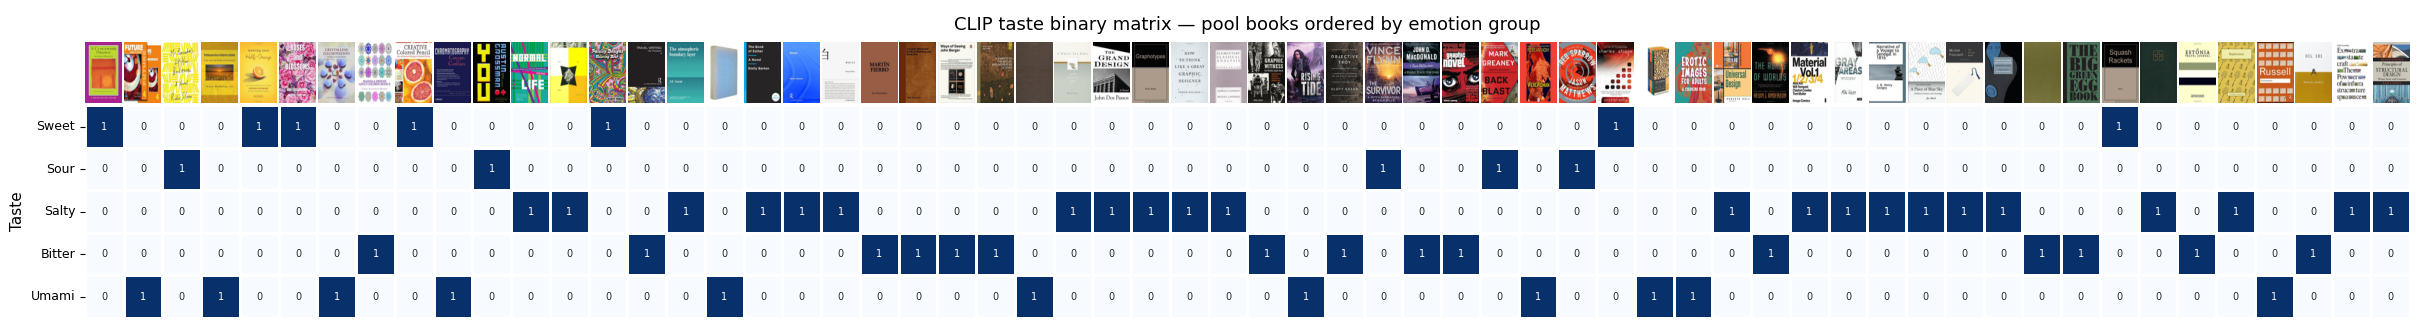

In [ ]:
df_clip_taste = pd.DataFrame(
    clip_taste_matrix.T,
    index=TASTES,
    columns=[f'B{i+1:02d}' for i in range(N)]
)

THUMB_H    = 0.8
MATRIX_H_T = 2.8
TOTAL_W    = 30

fig = plt.figure(figsize=(TOTAL_W, 0.4 + THUMB_H + MATRIX_H_T))
gs  = gridspec.GridSpec(
    3, N,
    height_ratios=[0.4, THUMB_H, MATRIX_H_T],   # ← row 0 = title space
    hspace=0.02, wspace=0.05
)

# Row 0: title
ax_title = fig.add_subplot(gs[0, :])
ax_title.axis('off')
ax_title.text(
    0.5, 0.5,
    'CLIP taste binary matrix — pool books ordered by emotion group',
    ha='center', va='center',
    fontsize=13, transform=ax_title.transAxes
)

# Row 1: thumbnails
for col_i, (path, em) in enumerate(zip(pool_image_paths, pool_emotions)):
    ax_img = fig.add_subplot(gs[1, col_i])
    ax_img.axis('off')
    color = EMOTION_COLORS.get(em, '#ccc')
    for spine in ax_img.spines.values():
        spine.set_edgecolor(color); spine.set_linewidth(3); spine.set_visible(True)
    if path and os.path.exists(path):
        try:
            img = Image.open(path).convert('RGB')
            img.thumbnail((80, 120))
            ax_img.imshow(np.array(img), aspect='auto')
        except:
            ax_img.set_facecolor('#eee')
    else:
        ax_img.set_facecolor('#eee')

# Row 2: heatmap
ax_heat = fig.add_subplot(gs[2, :])
sns.heatmap(
    df_clip_taste,
    ax=ax_heat,
    annot=True, fmt='',
    annot_kws={'size': 7},
    cmap='Blues', vmin=0, vmax=1,
    linewidths=0.8, linecolor='white',
    cbar=False,
)

ax_heat.set_xlabel('')
ax_heat.set_ylabel('Taste', fontsize=11)
ax_heat.tick_params(axis='x', bottom=False, labelbottom=False)
ax_heat.tick_params(axis='y', rotation=0, labelsize=9)

plt.savefig('clip_taste_binary_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

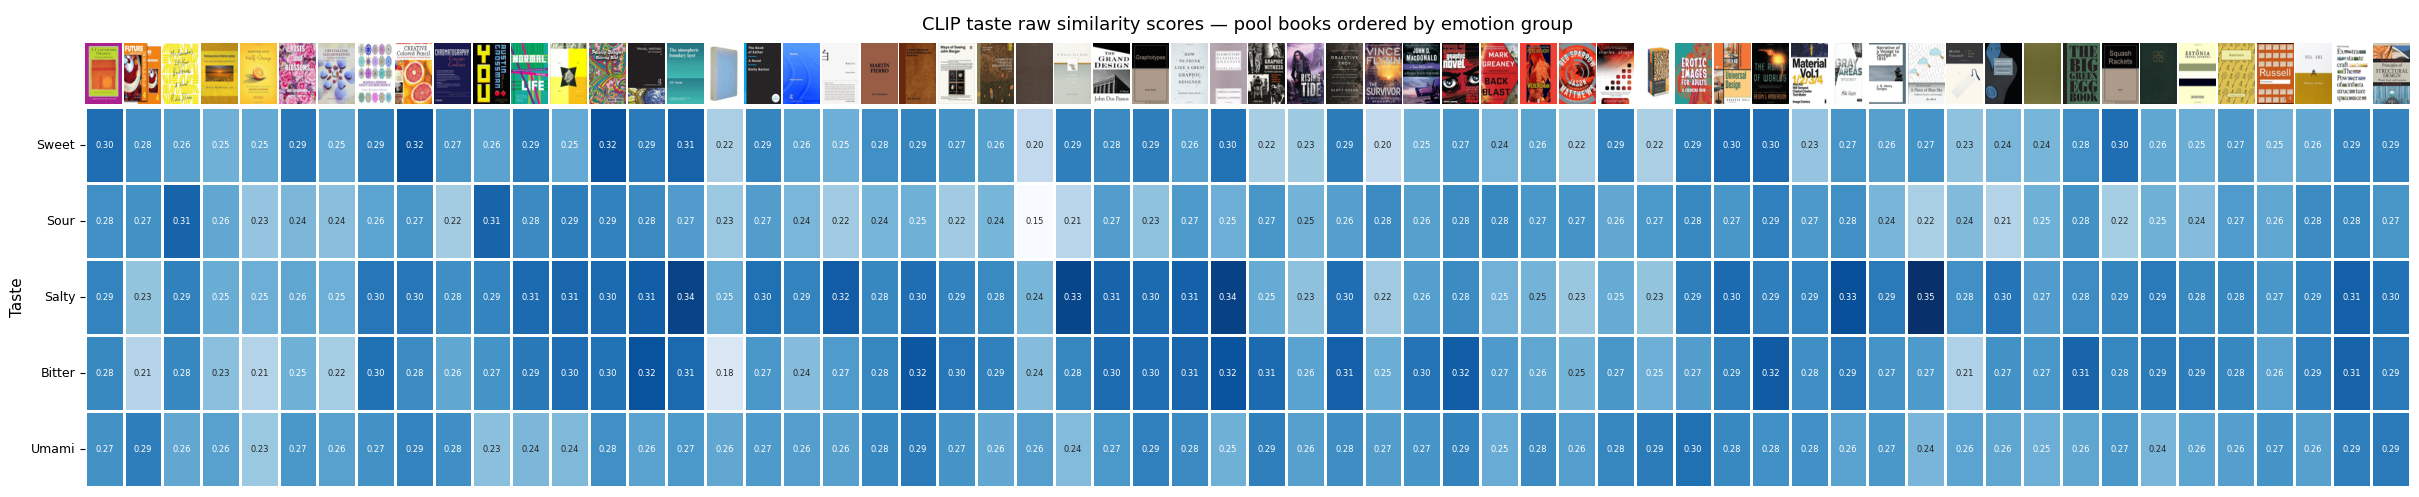

In [ ]:
df_clip_taste_raw = pd.DataFrame(
    clip_taste_scores.T,
    index=TASTES,
    columns=[f'B{i+1:02d}' for i in range(N)]
)

THUMB_H  = 0.8
MATRIX_H = 5.0
TOTAL_W  = 30

fig = plt.figure(figsize=(TOTAL_W, 0.4 + THUMB_H + MATRIX_H))
gs  = gridspec.GridSpec(3, N,
        height_ratios=[0.4, THUMB_H, MATRIX_H],
        hspace=0.02, wspace=0.05)

# Row 0: title
ax_title = fig.add_subplot(gs[0, :])
ax_title.axis('off')
ax_title.text(
    0.5, 0.5,
    'CLIP taste raw similarity scores — pool books ordered by emotion group',
    ha='center', va='center',
    fontsize=13, fontweight='normal',
    transform=ax_title.transAxes
)

# Row 1: thumbnails — exactly the same as binary cell
for col_i, (path, em) in enumerate(zip(pool_image_paths, pool_emotions)):
    ax_img = fig.add_subplot(gs[1, col_i])
    ax_img.axis('off')
    color = EMOTION_COLORS.get(em, '#ccc')
    for spine in ax_img.spines.values():
        spine.set_edgecolor(color); spine.set_linewidth(3); spine.set_visible(True)
    if path and os.path.exists(path):
        try:
            img = Image.open(path).convert('RGB')
            img.thumbnail((80, 120))
            ax_img.imshow(np.array(img), aspect='auto')
        except:
            ax_img.set_facecolor('#eee')
    else:
        ax_img.set_facecolor('#eee')

# Row 2: heatmap — only this part differs from the binary cell
ax_heat = fig.add_subplot(gs[2, :])
sns.heatmap(
    df_clip_taste_raw,
    ax=ax_heat,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 6},
    cmap='Blues',
    linewidths=0.8, linecolor='white',
    cbar=False,
)
ax_heat.set_xlabel('')
ax_heat.set_ylabel('Taste', fontsize=11)
ax_heat.tick_params(axis='x', bottom=False, labelbottom=False)
ax_heat.tick_params(axis='y', rotation=0, labelsize=9)

# plt.savefig('clip_emotion_raw_scores.png', dpi=150, bbox_inches='tight')
plt.show()

# Build human matrices

- Load Conjointly Excel files
- Load mapping file (q_to_book_mapping.xlsx)
- load_plurality_votes() for emotion study
- load_plurality_votes() for taste study
- Join by book title using mapping file
- Build human binary emotion matrix (60×12)
- Build human binary taste matrix (60×5)
- Heatmap: human emotion
- Heatmap: human taste

In [ ]:
from google.colab import drive
import re
from collections import Counter

drive.mount('/content/drive', force_remount=True)

# Assuming the Excel files are directly in the 'book-cover-dataset' folder in your Google Drive
EMOTION_FILE = '/content/drive/MyDrive/user-study/20260317_Conjointly_experiment_646348_export_at_0020.xlsx'
TASTE_FILE   = '/content/drive/MyDrive/user-study/20260316_Conjointly_experiment_646190_export_at_2316.xlsx'

print('Emotion file:', EMOTION_FILE)
print('Taste file:  ', TASTE_FILE)

#  load in the mapping file here

MAPPING_FILE = '/content/drive/MyDrive/user-study/q_to_book_mapping.xlsx'
print('MAPPING file:  ', MAPPING_FILE)

Mounted at /content/drive
Emotion file: /content/drive/MyDrive/user-study/20260317_Conjointly_experiment_646348_export_at_0020.xlsx
Taste file:   /content/drive/MyDrive/user-study/20260316_Conjointly_experiment_646190_export_at_2316.xlsx
MAPPING file:   /content/drive/MyDrive/user-study/q_to_book_mapping.xlsx


In [ ]:
import pandas as pd
import numpy as np

def load_plurality_votes(filepath, q_pattern):
    """
    Reads Respondents sheet, keeps completed surveys,
    finds book question columns (excluding Option columns),
    skips first 2 (trial rounds), returns list of per-book dicts.
    """
    df = pd.read_excel(filepath, sheet_name='Respondents', header=1)
    df.columns = df.iloc[0]
    df = df.iloc[1:].reset_index(drop=True)

    completed = df[df['Status of response'] == 'Completed survey'].copy()
    print(f'  Completed respondents: {len(completed)}')

    q_cols = [
        c for c in df.columns
        if isinstance(c, str)
        and re.search(q_pattern, c)
        and 'Option' not in c
    ]
    print(f'  Book question columns: {len(q_cols)}')

    results = []
    for pos, col in enumerate(q_cols, start=1):
        if pos <= 2:
            continue  # skip trial rounds
        counts = Counter(completed[col].dropna().str.strip())
        top1 = counts.most_common(1)[0][0] if counts else None
        results.append({
            'book': pos - 2,
            'top1': top1,
            'vote_counts': dict(counts),
            'n_votes': sum(counts.values()),
        })
    return results

print('Loading emotion data...')
emotion_data = load_plurality_votes(EMOTION_FILE, r'Q\d+:.*emotion.*\?$')

print('Loading taste data...')
taste_data   = load_plurality_votes(TASTE_FILE,   r'Q\d+:.*taste.*\?$')

print(f'\nReal books (trials excluded): {len(emotion_data)} emotion, {len(taste_data)} taste')

Loading emotion data...
  Completed respondents: 47
  Book question columns: 62
Loading taste data...
  Completed respondents: 42
  Book question columns: 62

Real books (trials excluded): 60 emotion, 60 taste


In [ ]:
import os, glob
from PIL import Image

IMAGE_FOLDER = '/content/drive/MyDrive/latest_llm'

all_images = (
    glob.glob(os.path.join(IMAGE_FOLDER, '**/*.jpg'),  recursive=True) +
    glob.glob(os.path.join(IMAGE_FOLDER, '**/*.jpeg'), recursive=True) +
    glob.glob(os.path.join(IMAGE_FOLDER, '**/*.png'),  recursive=True)
)
local_lookup = {os.path.basename(p): p for p in all_images}
print(f'Images found in folder: {len(local_lookup):,}')

# Load mapping — link emotion Q number → image filename
mapping    = pd.read_excel(MAPPING_FILE)
real_books = mapping[
    (mapping['is_trial'] == 'No') &
    mapping['image_filename'].notna() &
    (~mapping['image_filename'].astype(str).str.startswith('⚠')) &
    (~mapping['image_filename'].astype(str).str.startswith('trial'))
].copy()

# Q number → local image path
emotion_q_to_path = {
    int(row['emotion_Q (study 646348)']): local_lookup.get(row['image_filename'])
    for _, row in real_books.iterrows()
    if pd.notna(row['emotion_Q (study 646348)'])
}

taste_q_to_path = {
    int(row['taste_Q (study 646190)']): local_lookup.get(row['image_filename'])
    for _, row in real_books.iterrows()
    if pd.notna(row['taste_Q (study 646190)'])
}

print(f'Emotion Q→path entries: {len(emotion_q_to_path)}')
print(f'Taste   Q→path entries: {len(taste_q_to_path)}')

Images found in folder: 60
Emotion Q→path entries: 60
Taste   Q→path entries: 60


In [ ]:
# Load mapping
mapping    = pd.read_excel(MAPPING_FILE)
real_books = mapping[mapping['is_trial'] == 'No'].copy()

# Build Q number → row index (position 1..60 in order)
# emotion_data and taste_data are lists of dicts with key 'book' (1..60, position-based)
# We join by position — book 1 = first real Q in each study

# Sort real_books by emotion Q number to get consistent ordering
em_sorted = real_books.sort_values('emotion_Q (study 646348)').reset_index(drop=True)
ta_sorted = real_books.sort_values('taste_Q (study 646190)').reset_index(drop=True)

# book_title is the join key — use image_filename as the unique identifier instead
# since your mapping file uses image_filename as the key
all_filenames = em_sorted['image_filename'].tolist()
fname_to_idx  = {f: i for i, f in enumerate(all_filenames)}
N_BOOKS       = len(all_filenames)

# Build human binary matrices
emotion_matrix = np.zeros((N_BOOKS, len(EMOTIONS)), dtype=int)
taste_matrix   = np.zeros((N_BOOKS, len(TASTES)),   dtype=int)

EMOTIONS_LOWER = [e.lower() for e in EMOTIONS]
TASTES_LOWER   = [t.lower() for t in TASTES]

# emotion_data[i] corresponds to the i-th real book question in emotion study order
# match by position using em_sorted
for i, book in enumerate(emotion_data):
    if i >= len(em_sorted):
        break
    fname = em_sorted.iloc[i]['image_filename']
    row_i = fname_to_idx.get(fname)
    if row_i is None:
        continue
    label = str(book['top1']).lower() if book['top1'] else ''
    if label in EMOTIONS_LOWER:
        emotion_matrix[row_i, EMOTIONS_LOWER.index(label)] = 1

for i, book in enumerate(taste_data):
    if i >= len(ta_sorted):
        break
    fname = ta_sorted.iloc[i]['image_filename']
    row_i = fname_to_idx.get(fname)
    if row_i is None:
        continue
    label = str(book['top1']).lower() if book['top1'] else ''
    if label in TASTES_LOWER:
        taste_matrix[row_i, TASTES_LOWER.index(label)] = 1

print(f'emotion_matrix: {emotion_matrix.shape}')
print(f'taste_matrix:   {taste_matrix.shape}')

emotion_matrix: (60, 12)
taste_matrix:   (60, 5)


In [ ]:
import re

# Sort em_sorted by emotion group (the number before _r in image_filename)
def sort_key(fname):
    fname = str(fname)
    m = re.match(r'(\d+)_r(\d+)', fname)
    return (int(m.group(1)), int(m.group(2))) if m else (99, 99)

em_sorted_by_group = em_sorted.copy()
em_sorted_by_group['_sort'] = em_sorted_by_group['image_filename'].apply(sort_key)
em_sorted_by_group = em_sorted_by_group.sort_values('_sort').reset_index(drop=True)

# Build paths — try with .jpg and .png extensions since filename has no extension
def resolve_path(fname):
    fname = str(fname)
    for ext in ['.jpg', '.jpeg', '.png']:
        path = local_lookup.get(fname + ext)
        if path:
            return path
    return None

human_emotion_image_paths = [
    resolve_path(row['image_filename'])
    for _, row in em_sorted_by_group.iterrows()
]

# Also reorder the matrix columns to match this new sort order
new_col_order = [
    fname_to_idx[row['image_filename']]
    for _, row in em_sorted_by_group.iterrows()
    if row['image_filename'] in fname_to_idx
]
emotion_matrix_sorted = emotion_matrix[new_col_order, :]

df_emotion_display = pd.DataFrame(
    emotion_matrix_sorted.T,
    index=EMOTIONS,
    columns=[f'Book {i+1:02d}' for i in range(N_BOOKS)]
)

found = sum(1 for p in human_emotion_image_paths if p)
print(f'Images resolved: {found}/{N_BOOKS}')

Images resolved: 60/60


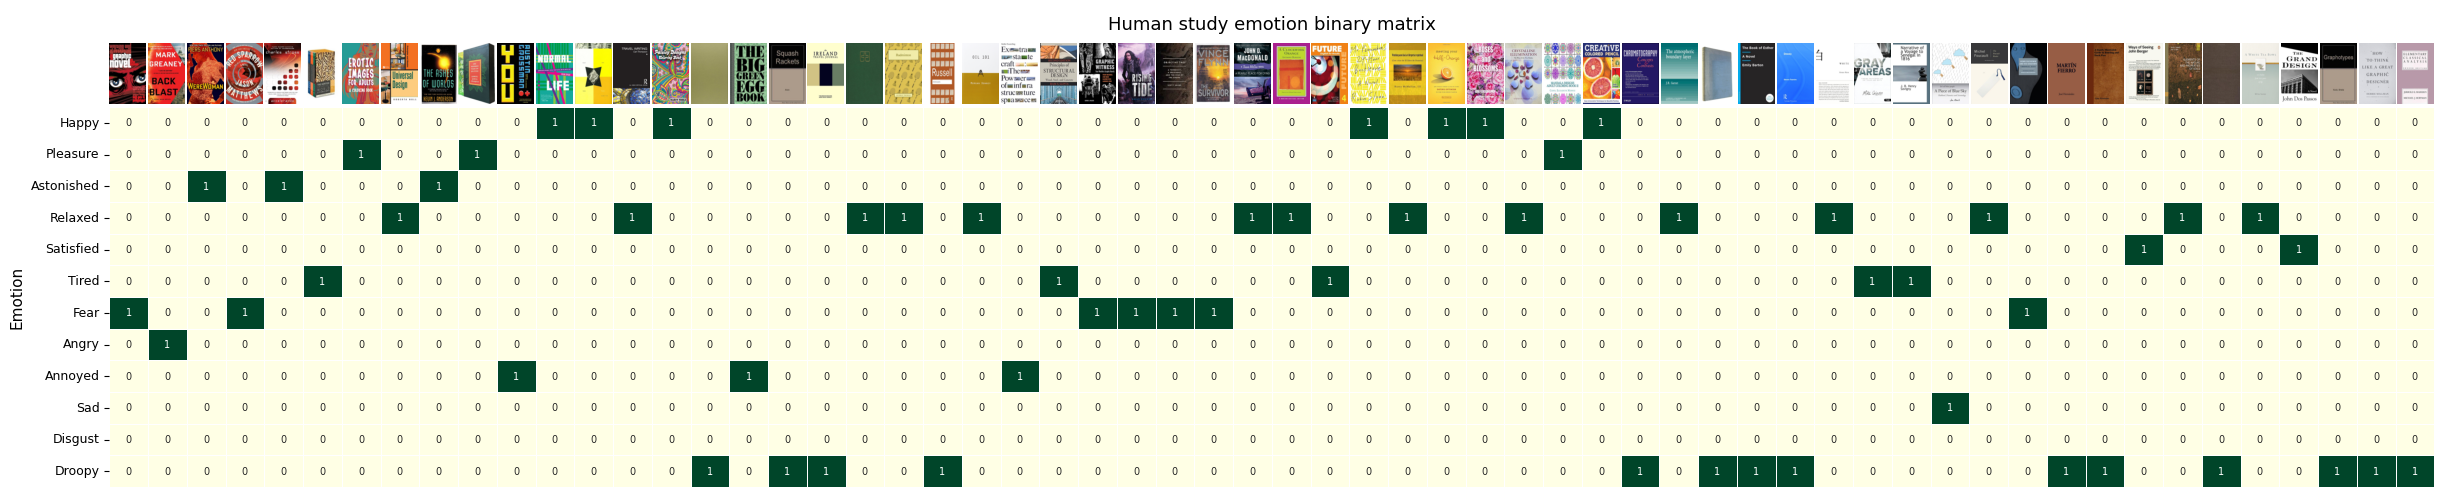

In [ ]:
import re
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image

# Sort by emotion group (0_r1, 0_r2 ... 11_r5)
def sort_key(fname):
    fname = str(fname)
    m = re.match(r'(\d+)_r(\d+)', fname)
    return (int(m.group(1)), int(m.group(2))) if m else (99, 99)

em_sorted_by_group = em_sorted.copy()
em_sorted_by_group['_sort'] = em_sorted_by_group['image_filename'].apply(sort_key)
em_sorted_by_group = em_sorted_by_group.sort_values('_sort').reset_index(drop=True)

# Resolve paths — try .jpg and .png since filename has no extension stored
def resolve_path(fname):
    fname = str(fname)
    for ext in ['.jpg', '.jpeg', '.png']:
        path = local_lookup.get(fname + ext)
        if path:
            return path
    return None

human_emotion_image_paths = [
    resolve_path(row['image_filename'])
    for _, row in em_sorted_by_group.iterrows()
]

# Reorder matrix columns to match new sort order
new_col_order = [
    fname_to_idx[row['image_filename']]
    for _, row in em_sorted_by_group.iterrows()
    if row['image_filename'] in fname_to_idx
]
emotion_matrix_sorted = emotion_matrix[new_col_order, :]

df_emotion_display = pd.DataFrame(
    emotion_matrix_sorted.T,
    index=EMOTIONS,
    columns=[f'Book {i+1:02d}' for i in range(N_BOOKS)]
)

found = sum(1 for p in human_emotion_image_paths if p)

# Plot
THUMB_H  = 0.8
MATRIX_H = 5.0
TOTAL_W  = 30

fig = plt.figure(figsize=(TOTAL_W, 0.4 + THUMB_H + MATRIX_H))
gs  = gridspec.GridSpec(3, N_BOOKS,
        height_ratios=[0.4, THUMB_H, MATRIX_H],
        hspace=0.02, wspace=0.05)

# Row 0: title
ax_title = fig.add_subplot(gs[0, :])
ax_title.axis('off')
ax_title.text(0.5, 0.5,
    'Human study emotion binary matrix',
    ha='center', va='center', fontsize=13, transform=ax_title.transAxes)

# Row 1: thumbnails
for col_i, path in enumerate(human_emotion_image_paths):
    ax_img = fig.add_subplot(gs[1, col_i])
    ax_img.axis('off')
    for spine in ax_img.spines.values():
        spine.set_edgecolor('#444'); spine.set_linewidth(1); spine.set_visible(True)
    if path and os.path.exists(path):
        try:
            img = Image.open(path).convert('RGB')
            img.thumbnail((80, 120))
            ax_img.imshow(np.array(img), aspect='auto')
        except:
            ax_img.set_facecolor('#eee')
    else:
        ax_img.set_facecolor('#eee')

# Row 2: heatmap
ax_heat = fig.add_subplot(gs[2, :])
sns.heatmap(
    df_emotion_display,
    ax=ax_heat, annot=True, fmt='d',
    cmap='YlGn', vmin=0, vmax=1,
    linewidths=0.4, linecolor='white',
    cbar=False, annot_kws={'size': 7},
)
ax_heat.set_xlabel('')
ax_heat.set_ylabel('Emotion', fontsize=11)
ax_heat.tick_params(axis='x', bottom=False, labelbottom=False)
ax_heat.tick_params(axis='y', rotation=0, labelsize=9)

plt.savefig('human_emotion_binary_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

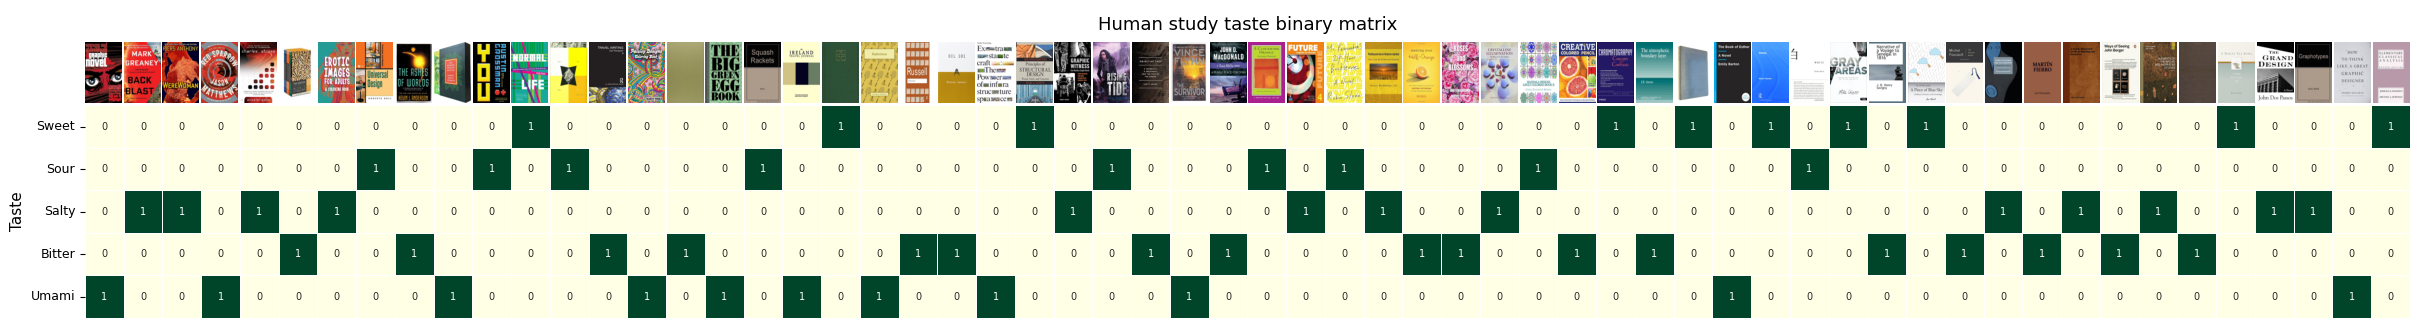

In [ ]:
# Sort ta_sorted by emotion group (same visual grouping as CLIP)
ta_sorted_by_group = ta_sorted.copy()
ta_sorted_by_group['_sort'] = ta_sorted_by_group['image_filename'].apply(sort_key)
ta_sorted_by_group = ta_sorted_by_group.sort_values('_sort').reset_index(drop=True)

human_taste_image_paths = [
    resolve_path(row['image_filename'])
    for _, row in ta_sorted_by_group.iterrows()
]

# Reorder matrix columns to match sort order
ta_col_order = [
    fname_to_idx[row['image_filename']]
    for _, row in ta_sorted_by_group.iterrows()
    if row['image_filename'] in fname_to_idx
]
taste_matrix_sorted = taste_matrix[ta_col_order, :]

df_taste_display = pd.DataFrame(
    taste_matrix_sorted.T,
    index=TASTES,
    columns=[f'Book {i+1:02d}' for i in range(N_BOOKS)]
)

found = sum(1 for p in human_taste_image_paths if p)

# Plot
THUMB_H    = 0.8
MATRIX_H_T = 2.8
TOTAL_W    = 30

fig = plt.figure(figsize=(TOTAL_W, 0.4 + THUMB_H + MATRIX_H_T))
gs  = gridspec.GridSpec(3, N_BOOKS,
        height_ratios=[0.4, THUMB_H, MATRIX_H_T],
        hspace=0.02, wspace=0.05)

# Row 0: title
ax_title = fig.add_subplot(gs[0, :])
ax_title.axis('off')
ax_title.text(0.5, 0.5,
    'Human study taste binary matrix',
    ha='center', va='center', fontsize=13, transform=ax_title.transAxes)

# Row 1: thumbnails
for col_i, path in enumerate(human_taste_image_paths):
    ax_img = fig.add_subplot(gs[1, col_i])
    ax_img.axis('off')
    for spine in ax_img.spines.values():
        spine.set_edgecolor('#444'); spine.set_linewidth(1); spine.set_visible(True)
    if path and os.path.exists(path):
        try:
            img = Image.open(path).convert('RGB')
            img.thumbnail((80, 120))
            ax_img.imshow(np.array(img), aspect='auto')
        except:
            ax_img.set_facecolor('#eee')
    else:
        ax_img.set_facecolor('#eee')

# Row 2: heatmap
ax_heat = fig.add_subplot(gs[2, :])
sns.heatmap(
    df_taste_display,
    ax=ax_heat, annot=True, fmt='d',
    cmap='YlGn', vmin=0, vmax=1,
    linewidths=0.4, linecolor='white',
    cbar=False, annot_kws={'size': 7},
)
ax_heat.set_xlabel('')
ax_heat.set_ylabel('Taste', fontsize=11)
ax_heat.tick_params(axis='x', bottom=False, labelbottom=False)
ax_heat.tick_params(axis='y', rotation=0, labelsize=9)

plt.savefig('human_taste_binary_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# for each -> if there's a match between taste x emotion --> output that book out --> put it as 1 for that combo (find the other combos if possible)

# loop through all 60 bookx, loop trough all participants

